# Module 09: Regression & Classification Modelling for CA Professionals

*Himalayan Advisory & Accounting Services Pvt. Ltd. — Kathmandu*

## Part 1: Why Does This Matter to You?

> "We spend 3 months every year chasing late payments from the same clients. We know who they are — we just can't prove it to management until the damage is done."
>
> — Senior CA Partner, Kathmandu-based accounting firm

Every CA firm carries **credit risk** on every invoice it issues. Right now, most firms manage this with gut feel and experience. Regression and classification models let you replace intuition with a number that says:

*"This client has a 73% probability of paying late. You should require advance payment or reduce their credit limit."*

This is not futuristic AI. It is **applied statistics on your own ERP data** — and after this module, you will be able to build it in 30 minutes.

### The Business Problem

**Himalayan Advisory** has 900 invoices in its ledger. The partner wants a system that:

| Question | Model Type | Output |
|----------|-----------|--------|
| Will this client pay late? | Classification | Yes / No |
| How many days will they be late? | Regression | 12 days, 45 days... |
| Which clients should get a credit limit reduction? | Classification | Risk tier |

We already have `nepal_invoice_features.csv` from Module 08 — **42 engineered features ready to go**.

## Part 2: Fundamentals

### What is a Model?

A model is a mathematical function that maps inputs (features) to outputs (predictions):

```
f(invoice_credit_ratio, prev_late_rate, industry, ...) → Is_Late (0 or 1)
```

The model **learns** this function from historical data where we already know the answer.

### Two Families of Models

| Family | Task | Target | Example |
|--------|------|--------|---------|
| **Regression** | Predict a continuous number | Days delayed, Invoice amount | Linear Regression |
| **Classification** | Predict a category / probability | Late or Not Late | Logistic Regression, Random Forest |

**Logistic Regression** is the workhorse of binary classification (yes/no outcomes). Despite its name, it is a *classification* model — it predicts the *probability* of an event.

### The Modelling Workflow

```
Raw Data
   │
   ▼
Feature Engineering (Module 08) ←── already done!
   │
   ▼
Train / Test Split
   │
   ▼
Fit Model on Training Data
   │
   ▼
Predict on Test Data
   │
   ▼
Evaluate (Accuracy, Precision, Recall, AUC-ROC)
   │
   ▼
Interpret → Business Recommendations
```

### Why Train/Test Split?

A model that memorises training data perfectly will fail on new data — this is called **overfitting**.

We hold back 20–30% of the data (the **test set**) to simulate how the model performs on invoices it has never seen.

```
All 900 invoices
├── 720 Training  → model learns from these
└── 180 Test      → we evaluate on these (model has never seen them)
```

**Key rule:** Never use test data to make any decisions until the very end. Treat it like future invoices.

### Evaluation Metrics — The CA Interpretation

| Metric | Formula | CA Interpretation |
|--------|---------|------------------|
| **Accuracy** | Correct / Total | % invoices classified correctly |
| **Precision** | TP / (TP + FP) | Of invoices flagged as risky, how many were actually late? |
| **Recall** | TP / (TP + FN) | Of all late invoices, how many did we catch? |
| **F1 Score** | Harmonic mean of P & R | Balanced measure |
| **AUC-ROC** | Area under ROC curve | 0.5 = random; 1.0 = perfect |

**For collections risk:** Recall matters more than Precision.
Missing a late payer (False Negative) costs you real NPR. A false alarm (False Positive) is just an awkward conversation.

## Part 3: Hands-on — Build and Evaluate Two Models

### Section 1: Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

# Load engineered features from Module 08
df = pd.read_csv('nepal_invoice_features.csv')

print(f'Loaded: {df.shape[0]} invoices, {df.shape[1]} columns')
print(f'Late payers: {df["Is_Late"].sum()} ({df["Is_Late"].mean()*100:.1f}%)')
print(f'\nColumns ({len(df.columns)}):')
print(', '.join(df.columns.tolist()))

Loaded: 900 invoices, 40 columns
Late payers: 272 (30.2%)

Columns (40):
invoice_credit_ratio, prev_late_rate, amount_vs_industry_median, daily_obligation, is_high_utilisation, is_repeat_offender, is_clean_record, is_first_time_client, is_long_term_client, is_high_risk_industry, is_mega_invoice, is_Q4_due, is_dashain_season, is_vat_filing_month, invoice_quarter, due_quarter, days_to_fy_end, due_on_weekend, industry_target_enc, tenure_band, amount_band_ord, utilisation_x_history, risk_x_amount, q4_x_late_history, manual_risk_score, client_total_invoices, client_avg_invoice, client_avg_delay, client_late_rate, client_late_count, Invoice_Amount, Tenure_Years, Prev_Late_Count, Credit_Days, Invoice_ID, Client_ID, Client_Name, Industry, Province, Is_Late


### Section 2: Prepare Features and Target

In [2]:
# Feature columns (numeric only — already engineered in Module 08)
feature_cols = [
    # Ratio features
    'invoice_credit_ratio', 'prev_late_rate', 'amount_vs_industry_median', 'daily_obligation',
    # Binary flags
    'is_high_utilisation', 'is_repeat_offender', 'is_clean_record',
    'is_first_time_client', 'is_long_term_client', 'is_high_risk_industry',
    'is_mega_invoice', 'is_Q4_due', 'is_dashain_season', 'is_vat_filing_month',
    # Date features
    'invoice_quarter', 'due_quarter', 'days_to_fy_end',
    # Categorical encodings
    'industry_target_enc', 'tenure_band', 'amount_band_ord',
    # Interaction features
    'utilisation_x_history', 'risk_x_amount', 'q4_x_late_history',
    'new_client_x_utilisation', 'manual_risk_score',
    # Aggregation features
    'client_late_rate', 'client_avg_delay', 'client_total_invoices', 'client_avg_invoice',
]

# Keep only columns that exist in the loaded CSV
feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols].copy()
y = df['Is_Late'].copy()

print(f'Feature matrix shape: {X.shape}')
print(f'Target: {y.value_counts().to_dict()}')
print(f'\nMissing values in features:')
missing = X.isnull().sum()
print(missing[missing > 0] if missing.any() else '  None — clean dataset!')

Feature matrix shape: (900, 28)
Target: {0: 628, 1: 272}

Missing values in features:
  None — clean dataset!


In [3]:
# Train / Test split — stratify to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # Hold back 20% as unseen test invoices
    random_state=42,
    stratify=y           # Ensure both splits have the same late-payer ratio
)

print(f'Training set:  {X_train.shape[0]} invoices ({y_train.mean()*100:.1f}% late)')
print(f'Test set:      {X_test.shape[0]} invoices  ({y_test.mean()*100:.1f}% late)')

Training set:  720 invoices (30.3% late)
Test set:      180 invoices  (30.0% late)


### Section 3: Model 1 — Logistic Regression

Logistic Regression is the simplest and most interpretable classifier. It learns a weight for each feature, making it easy to explain to a CA partner: "The model penalises a high `prev_late_rate` by X and rewards a `is_clean_record` flag by Y." 

In [4]:
# Scale features — Logistic Regression is sensitive to scale
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)   # Use training scale on test — never refit!

# Fit Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_sc, y_train)

# Predictions
y_pred_lr  = lr.predict(X_test_sc)
y_prob_lr  = lr.predict_proba(X_test_sc)[:, 1]   # Probability of being late

print('=== Logistic Regression — Test Set Results ===')
print()
print(classification_report(y_test, y_pred_lr,
                             target_names=['On Time', 'Late >60d']))

=== Logistic Regression — Test Set Results ===

              precision    recall  f1-score   support

     On Time       0.90      0.64      0.75       126
   Late >60d       0.50      0.83      0.62        54

    accuracy                           0.70       180
   macro avg       0.70      0.74      0.69       180
weighted avg       0.78      0.70      0.71       180



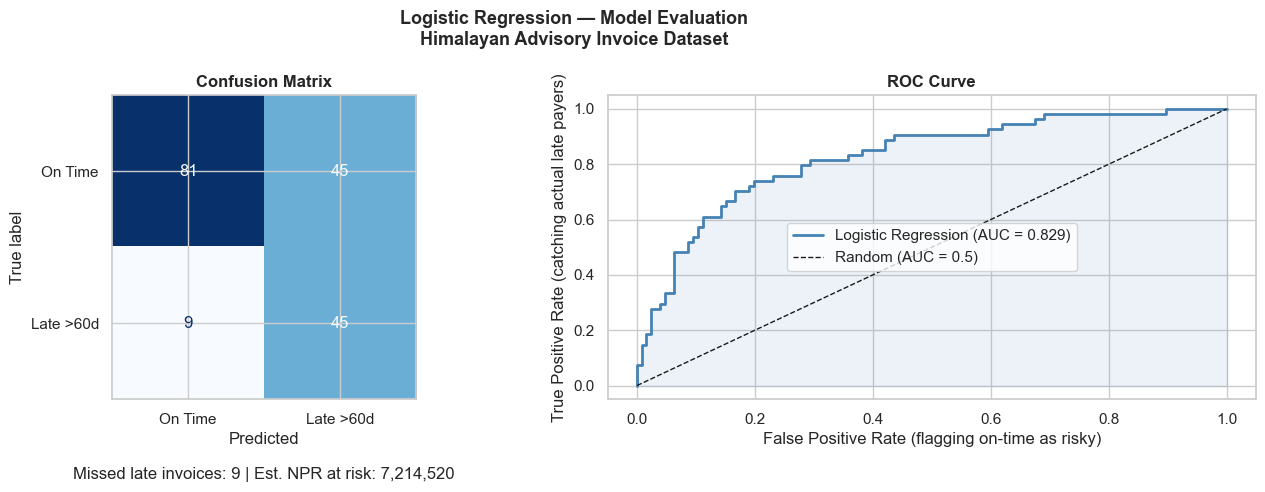

AUC-ROC: 0.8286  (1.0 = perfect, 0.5 = random guess)


In [5]:
# Visualise Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Logistic Regression — Model Evaluation\nHimalayan Advisory Invoice Dataset',
             fontsize=13, fontweight='bold')

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['On Time', 'Late >60d'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')

# Add NPR cost annotation
tn, fp, fn, tp = cm_lr.ravel()
avg_invoice = df['Invoice_Amount'].mean() if 'Invoice_Amount' in df.columns else 350000
missed_revenue = fn * avg_invoice
axes[0].set_xlabel(f'Predicted\n\nMissed late invoices: {fn} | Est. NPR at risk: {missed_revenue:,.0f}')

# ROC Curve
auc_lr = roc_auc_score(y_test, y_prob_lr)
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'Logistic Regression (AUC = {auc_lr:.3f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Random (AUC = 0.5)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='steelblue')
axes[1].set_xlabel('False Positive Rate (flagging on-time as risky)')
axes[1].set_ylabel('True Positive Rate (catching actual late payers)')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'AUC-ROC: {auc_lr:.4f}  (1.0 = perfect, 0.5 = random guess)')

### Section 4: Model 2 — Random Forest

Random Forest builds hundreds of decision trees and averages their votes. It handles non-linear relationships and interactions automatically — no need to manually engineer interaction features. It also provides **feature importance** scores: which variables drive the prediction most?

In [6]:
# Random Forest — no scaling needed
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest — Test Set Results ===')
print()
print(classification_report(y_test, y_pred_rf,
                             target_names=['On Time', 'Late >60d']))

=== Random Forest — Test Set Results ===

              precision    recall  f1-score   support

     On Time       0.85      0.67      0.75       126
   Late >60d       0.49      0.72      0.58        54

    accuracy                           0.69       180
   macro avg       0.67      0.70      0.67       180
weighted avg       0.74      0.69      0.70       180



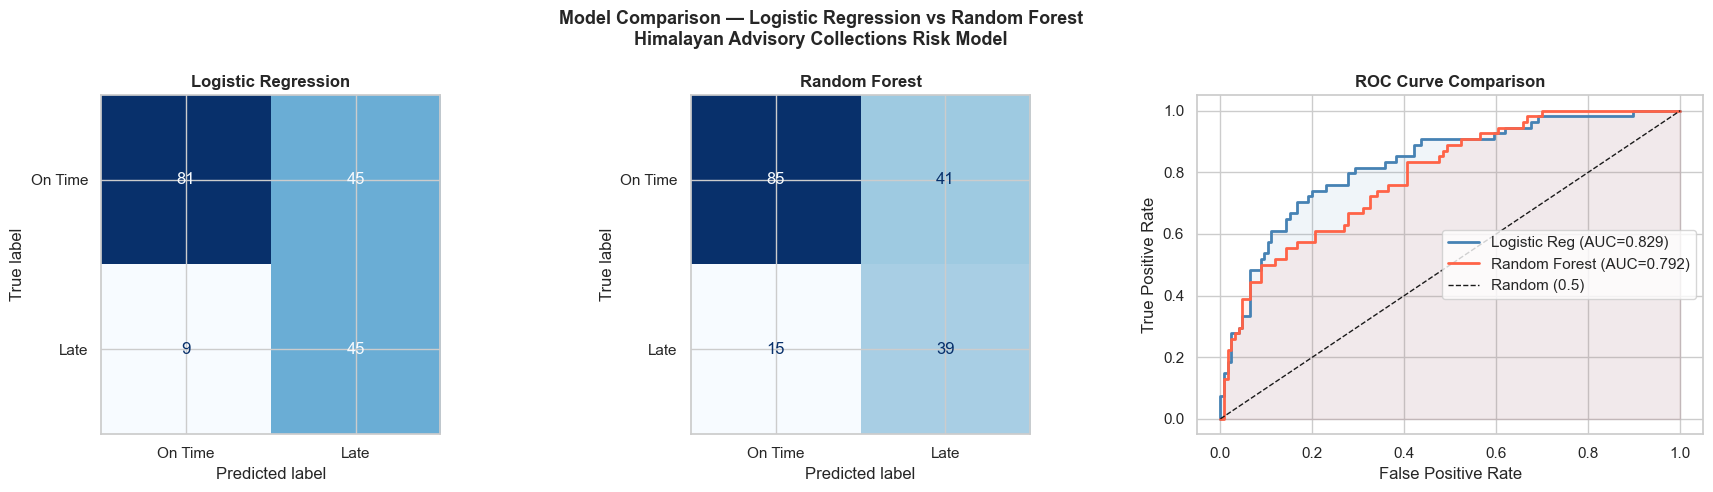

Logistic Regression AUC: 0.8286
Random Forest AUC:       0.7925

Winner: Logistic Regression


In [7]:
# Compare both models side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Comparison — Logistic Regression vs Random Forest\nHimalayan Advisory Collections Risk Model',
             fontsize=13, fontweight='bold')

# Confusion matrices
for ax, y_pred, title in zip(axes[:2],
    [y_pred_lr, y_pred_rf],
    ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['On Time', 'Late']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')

# ROC Curves overlaid
auc_rf = roc_auc_score(y_test, y_prob_rf)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

axes[2].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'Logistic Reg (AUC={auc_lr:.3f})')
axes[2].plot(fpr_rf, tpr_rf, color='tomato', lw=2,
             label=f'Random Forest (AUC={auc_rf:.3f})')
axes[2].plot([0,1],[0,1],'k--', lw=1, label='Random (0.5)')
axes[2].fill_between(fpr, tpr, alpha=0.08, color='steelblue')
axes[2].fill_between(fpr_rf, tpr_rf, alpha=0.08, color='tomato')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve Comparison', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Logistic Regression AUC: {auc_lr:.4f}')
print(f'Random Forest AUC:       {auc_rf:.4f}')
better = 'Random Forest' if auc_rf > auc_lr else 'Logistic Regression'
print(f'\nWinner: {better}')

### Section 5: Feature Importance — What Drives Late Payments?

Random Forest gives us a **feature importance** score for each variable. This is the answer to the partner's question: *"Which client characteristics should I actually care about?"*

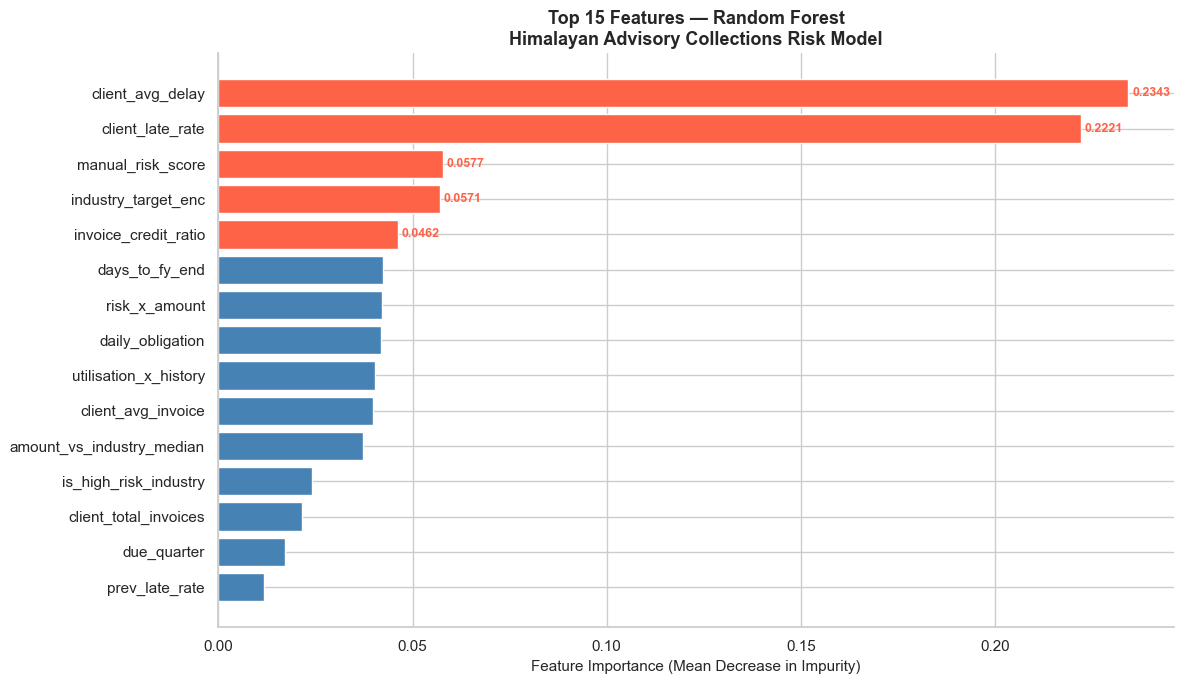

Top 5 most important features:
  client_avg_delay                    0.2343  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  client_late_rate                    0.2221  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████
  manual_risk_score                   0.0577  ████████████████████████████
  industry_target_enc                 0.0571  ████████████████████████████
  invoice_credit_ratio                0.0462  ███████████████████████


In [8]:
# Feature importance from Random Forest
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))

colors = ['tomato' if i < 5 else 'steelblue' for i in range(len(importance_df))]
bars = ax.barh(importance_df['Feature'][::-1],
               importance_df['Importance'][::-1],
               color=colors[::-1], edgecolor='white')

ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_title('Top 15 Features — Random Forest\nHimalayan Advisory Collections Risk Model',
             fontsize=13, fontweight='bold')

# Annotate top 5
for bar, val in zip(bars[-5:], importance_df['Importance'][:5][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, fontweight='bold', color='tomato')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
for i, row in importance_df.head(5).iterrows():
    bar = '█' * int(row['Importance'] * 500)
    print(f'  {row["Feature"]:<35} {row["Importance"]:.4f}  {bar}')

### Section 6: Risk-Scored Invoice Report

The ultimate output: a ranked list of the riskiest invoices, with a probability score the partner can use to prioritise collections calls.

In [9]:
# Score all invoices with Random Forest probabilities
df_scored = df.copy()
X_all_sc = X.copy()
X_all_filled = X_all_sc.fillna(X_all_sc.median())
df_scored['Late_Probability'] = rf.predict_proba(X_all_filled)[:, 1]

# Assign risk tier
def risk_tier(p):
    if p >= 0.70: return '🔴 High Risk'
    elif p >= 0.45: return '🟡 Medium Risk'
    else: return '🟢 Low Risk'

df_scored['Risk_Tier'] = df_scored['Late_Probability'].apply(risk_tier)

# Summary by tier
print('=== Risk Tier Summary ===')
tier_summary = df_scored.groupby('Risk_Tier').agg(
    Count=('Invoice_ID', 'count'),
    Avg_Late_Prob=('Late_Probability', 'mean'),
    Actual_Late_Rate=('Is_Late', 'mean')
).round(3)
tier_summary['Actual_Late_Rate_%'] = (tier_summary['Actual_Late_Rate'] * 100).round(1)
print(tier_summary[['Count','Avg_Late_Prob','Actual_Late_Rate_%']].to_string())

# Show highest risk invoices
print('\n=== Top 10 Highest Risk Invoices ===')
top_risk_cols = ['Client_ID', 'Client_Name', 'Industry', 'Late_Probability', 'Risk_Tier', 'Is_Late']
available_cols = [c for c in top_risk_cols if c in df_scored.columns]
print(df_scored.nlargest(10, 'Late_Probability')[available_cols].to_string(index=False))

=== Risk Tier Summary ===
               Count  Avg_Late_Prob  Actual_Late_Rate_%
Risk_Tier                                              
🔴 High Risk      125          0.792                92.0
🟡 Medium Risk    280          0.572                50.0
🟢 Low Risk       495          0.207                 3.4

=== Top 10 Highest Risk Invoices ===
Client_ID                    Client_Name         Industry  Late_Probability   Risk_Tier  Is_Late
   NP0164  Lumbini Hospitality Pvt. Ltd. Tourism & Hotels          0.911294 🔴 High Risk        1
   NP0053      Everest Imports Pvt. Ltd. Trading & Import          0.903303 🔴 High Risk        1
   NP0192  Lumbini Hospitality Pvt. Ltd. Tourism & Hotels          0.889083 🔴 High Risk        1
   NP0164        Sagarmatha Trekking Co. Tourism & Hotels          0.885819 🔴 High Risk        1
   NP0053 Nepal Infrastructure Pvt. Ltd.     Construction          0.884960 🔴 High Risk        1
   NP0157    Himalayan Traders Pvt. Ltd. Trading & Import          0.88193

In [10]:
# Export risk-scored report
export_cols = ['Invoice_ID','Client_ID','Client_Name','Industry','Province',
               'Late_Probability','Risk_Tier','Is_Late']
export_cols = [c for c in export_cols if c in df_scored.columns]

df_scored.sort_values('Late_Probability', ascending=False)[export_cols].to_excel(
    'nepal_invoice_risk_scores.xlsx', index=False)

print('Risk-scored report saved to nepal_invoice_risk_scores.xlsx')
print(f'\nTotal invoices scored: {len(df_scored)}')
print(df_scored['Risk_Tier'].value_counts().to_string())

Risk-scored report saved to nepal_invoice_risk_scores.xlsx

Total invoices scored: 900
Risk_Tier
🟢 Low Risk       495
🟡 Medium Risk    280
🔴 High Risk      125


## Part 4: Practice Exercises

---

#### Exercise 1 — Threshold Tuning

By default, `predict()` classifies as Late if probability ≥ 0.5. But for a conservative CA firm, you may prefer to flag invoices with probability ≥ 0.35 as risky.

1. Using `y_prob_rf` (Random Forest probabilities on the test set), classify as Late if probability ≥ 0.35
2. Print the `classification_report` for this threshold
3. Compare Recall and Precision vs the default 0.5 threshold. What is the tradeoff?

---

#### Exercise 2 — Industry-Level Risk Report

Create a summary DataFrame showing, by Industry:
- Total invoices
- Average `Late_Probability` (from `df_scored`)
- Actual late rate (%)
- Count of High Risk invoices

Sort by average `Late_Probability` descending. Which industry should Himalayan Advisory tighten credit terms for?

---

#### Exercise 3 — Logistic Regression Coefficients

Logistic Regression coefficients tell you the direction and strength of each feature's effect.

1. Create a DataFrame of feature names and their LR coefficients (`lr.coef_[0]`)
2. Sort by absolute coefficient value (descending)
3. Plot a horizontal bar chart — positive coefficients in red (increase late risk), negative in green (reduce risk)
4. Write 2 sentences interpreting the top positive and top negative coefficient for a non-technical partner

---

*Solutions in cells below.*

---

In [11]:
# SOLUTION — Exercise 1: Threshold Tuning
threshold = 0.35
y_pred_35 = (y_prob_rf >= threshold).astype(int)

print(f'=== Random Forest — Threshold = {threshold} ===')
print(classification_report(y_test, y_pred_35, target_names=['On Time', 'Late >60d']))

from sklearn.metrics import precision_score, recall_score
print('Comparison:')
print(f'  Threshold 0.5  →  Precision: {precision_score(y_test, y_pred_rf):.3f}  Recall: {recall_score(y_test, y_pred_rf):.3f}')
print(f'  Threshold 0.35 →  Precision: {precision_score(y_test, y_pred_35):.3f}  Recall: {recall_score(y_test, y_pred_35):.3f}')
print()
print('Interpretation: Lower threshold catches more late payers (higher Recall)')
print('but also flags more on-time payers as risky (lower Precision).')

=== Random Forest — Threshold = 0.35 ===
              precision    recall  f1-score   support

     On Time       0.93      0.43      0.59       126
   Late >60d       0.41      0.93      0.57        54

    accuracy                           0.58       180
   macro avg       0.67      0.68      0.58       180
weighted avg       0.77      0.58      0.58       180

Comparison:
  Threshold 0.5  →  Precision: 0.487  Recall: 0.722
  Threshold 0.35 →  Precision: 0.410  Recall: 0.926

Interpretation: Lower threshold catches more late payers (higher Recall)
but also flags more on-time payers as risky (lower Precision).


In [12]:
# SOLUTION — Exercise 2: Industry-Level Risk Report
industry_risk = df_scored.groupby('Industry').agg(
    Total_Invoices=('Invoice_ID', 'count'),
    Avg_Late_Prob=('Late_Probability', 'mean'),
    Actual_Late_Rate=('Is_Late', 'mean'),
    High_Risk_Count=('Risk_Tier', lambda x: (x == '🔴 High Risk').sum())
).round(3)

industry_risk['Actual_Late_Rate_%'] = (industry_risk['Actual_Late_Rate'] * 100).round(1)
industry_risk = industry_risk[['Total_Invoices','Avg_Late_Prob','Actual_Late_Rate_%','High_Risk_Count']]
industry_risk = industry_risk.sort_values('Avg_Late_Prob', ascending=False)

print('=== Industry Risk Report — Himalayan Advisory ===')
print(industry_risk.to_string())
print()
print(f'Recommendation: Tighten credit terms for {industry_risk.index[0]}')
print(f'(Avg late probability: {industry_risk["Avg_Late_Prob"].iloc[0]:.1%})')

=== Industry Risk Report — Himalayan Advisory ===
                   Total_Invoices  Avg_Late_Prob  Actual_Late_Rate_%  High_Risk_Count
Industry                                                                             
Construction                  107          0.543                45.8               32
Tourism & Hotels              108          0.510                42.6               32
Trading & Import              213          0.480                36.2               41
Manufacturing                 144          0.371                27.1               13
Agriculture                    47          0.352                25.5                3
Hydropower                    120          0.296                19.2                3
Services & IT                  86          0.280                19.8                1
Banking & Finance              75          0.225                12.0                0

Recommendation: Tighten credit terms for Construction
(Avg late probability: 54.3%)


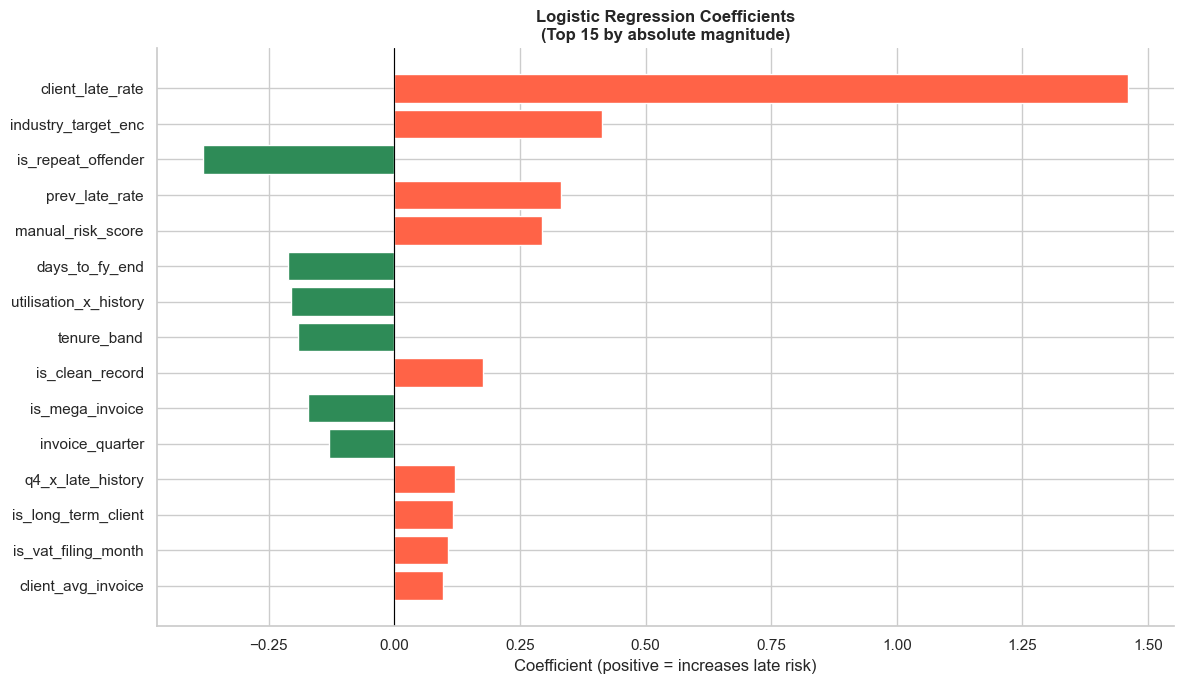

Top risk-increasing feature: client_late_rate (coef=1.460)
Top risk-reducing feature:   is_repeat_offender (coef=-0.380)

Interpretation: A higher client_late_rate strongly predicts late payment.
Conversely, is_repeat_offender reduces the probability of late payment.


In [13]:
# SOLUTION — Exercise 3: Logistic Regression Coefficients
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['tomato' if c > 0 else 'seagreen' for c in coef_df['Coefficient'][::-1]]
ax.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1],
        color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (positive = increases late risk)')
ax.set_title('Logistic Regression Coefficients\n(Top 15 by absolute magnitude)',
             fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

top_pos = coef_df[coef_df['Coefficient'] > 0].iloc[0]
top_neg = coef_df[coef_df['Coefficient'] < 0].iloc[0]
print(f'Top risk-increasing feature: {top_pos["Feature"]} (coef={top_pos["Coefficient"]:.3f})')
print(f'Top risk-reducing feature:   {top_neg["Feature"]} (coef={top_neg["Coefficient"]:.3f})')
print()
print('Interpretation: A higher', top_pos["Feature"], 'strongly predicts late payment.')
print('Conversely,', top_neg["Feature"], 'reduces the probability of late payment.')